In [1]:
# Chargement du dataset pretraite
import pandas as pd
df = pd.read_csv('../data/avis_pretraite.csv')
df.head()

,avis_clients,avis nettoye,lang,tokens,text_lemmas,longueur
0,Le spa propose un traitement signature exclusi...,le spa propose un traitement signature exclusi...,fr,"['spa', 'proposer', 'traitement', 'signatur', ...",spa proposer traitement signatur exclusif deve...,20
1,Un séjour correct mais qui ne justifie pas ple...,un sejour correct mais qui ne justifie pas ple...,fr,"['sejour', 'correct', 'justifier', 'pleinement...",sejour correct justifier pleinement classement...,23
2,The laundry service express saved our gala din...,the laundry service express saved our gala din...,en,"['exposition', 'collection', 'art', 'contempor...",exposition collection art contemporain hotel p...,13
3,L'exposition de collection d'art contemporain ...,l'exposition de collection d'art contemporain ...,fr,"['emplacement', 'privilegie', 'parfaire', 'exp...",emplacement privilegie parfaire explorer ville...,24
4,L'emplacement privilégié est parfait pour expl...,l'emplacement privilegie est parfait pour expl...,fr,"['petit', 'dejeuner', 'buffet', 'varier', 'raf...",petit dejeuner buffet varier raffine reapprovi...,18


In [2]:
# Apercu des colonnes
df.columns

Index(['avis_clients', 'avis nettoye', 'lang', 'tokens', 'text_lemmas',
       'longueur'],
      dtype='object')

In [3]:
# Analyse thematique
corpus = df['text_lemmas'].astype(str).tolist()
corpus[:5]

['spa proposer traitement signatur exclusif developpe aromatherapeute renommee mondial specialemer hotel promenade',
 'sejour correct justifier pleinement classement lux service professionnel touche personnel faire difference',
 'exposition collection art contemporain hotel presentee visite privee historien art passionne revel subtilite',
 'emplacement privilegie parfaire explorer ville service navette pouvoir proposer destination culturel',
 'petit dejeuner buffet varier raffine reapprovisionnement eter lent periode fort affluence week end autour rideau canal']

In [4]:
# Verification de la longueur du corpus
import numpy as np

longueurs = [len(text.split()) for text in corpus]
print("Longueur moyenne :", np.mean(longueurs))
print("Longueur max :", np.max(longueurs))
print("Longueur min :", np.min(longueurs))

Longueur moyenne : 61.35660218671152
Longueur max : 1356
Longueur min : 3


In [5]:
# Verifier si pas de texte vide
textes_vides = [text for text in corpus if len(text.strip()) == 0]
print("Nombre de textes vides :", len(textes_vides))

Nombre de textes vides : 0


In [6]:
# Construction du modele TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 1)
)
X_tfidf = tfidf.fit_transform(corpus)
print("Taille de la matrice TF-IDF :", X_tfidf.shape)

Taille de la matrice TF-IDF : (5945, 9575)


In [7]:
# Extraction des mots ls plus importants
feature_names = tfidf.get_feature_names_out()
tfidf_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
tfidf_scores = pd.DataFrame({
    'mot': feature_names, 
    'score': tfidf_mean
}).sort_values(by='score', ascending=False)
print(tfidf_scores.head(20))

             mot     score
7302        room  0.055769
6605   promenade  0.038275
5896      ottawa  0.034784
3849       great  0.031964
8137        stay  0.030345
8073       staff  0.028335
7305       rooms  0.026470
7584     service  0.026157
4977    location  0.025587
3783        good  0.024414
8138      stayed  0.022943
1587       clean  0.019855
7825       small  0.019264
8656        time  0.019015
6046  parliament  0.017756
5620        nice  0.017654
4966       lobby  0.016968
5630       night  0.016382
1465       check  0.015718
4058     helpful  0.015411


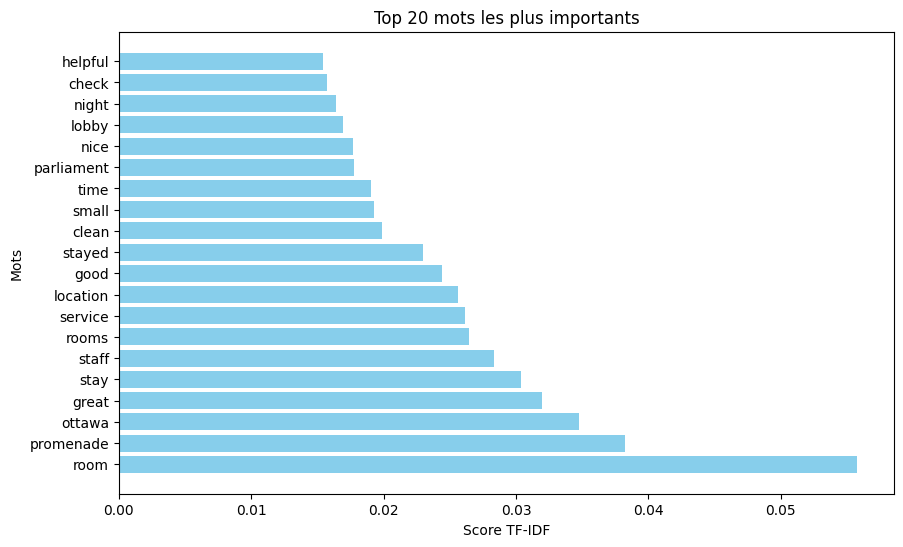

In [8]:
# Visualisation des scores TF-IDF
import matplotlib.pyplot as plt

top_n = 20
top_features = tfidf_scores.head(top_n)
plt.figure(figsize=(10, 6))
plt.barh(top_features['mot'], top_features['score'], color='skyblue')
plt.xlabel('Score TF-IDF')
plt.title(f'Top {top_n} mots les plus importants')
plt.ylabel('Mots')
plt.show()

In [9]:
# Dimension de la matrice TF-IDF
print("Nombre de documents :", X_tfidf.shape)


Nombre de documents : (5945, 9575)


# Analyse des n-grammes (bigrams et trigrams)

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Fonction pour extraire les n-grams les plus fréquents
def get_top_ngrams(corpus, ngram_range=(2,2), top_n=20):
    vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=2)
    X = vectorizer.fit_transform(corpus)
    
    counts = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    
    df_ngrams = pd.DataFrame({
        'ngram': vocab,
        'count': counts
    }).sort_values(by='count', ascending=False)
    
    return df_ngrams.head(top_n)

In [11]:
# Extraction des bigrams
top_bigrams = get_top_ngrams(corpus, ngram_range=(2, 2), top_n=20)
print(top_bigrams)

                      ngram  count
15390       hotel promenade   5568
4241          byward market    954
22612       parliament hill    932
31236          stayed hotel    799
30980            stay hotel    704
26651          rideau canal    671
27418          room service    510
22609  parliament buildings    436
13358        great location    417
30406        staff friendly    399
20193      national gallery    383
35244      walking distance    363
30093         sparks street    331
27446            room small    325
1143               art deco    312
25901       recommend hotel    309
32808             tick tock    297
27069            room floor    284
22008          ottawa hotel    254
27876           rooms small    252


In [12]:
# Extraction des trigrams
top_trigrams = get_top_ngrams(corpus, ngram_range=(3, 3), top_n=20)
print(top_trigrams)

                           ngram  count
13705     stayed hotel promenade    713
13573       stay hotel promenade    533
14232            tick tock diner    236
8597     national gallery canada    217
13807    staying hotel promenade    170
14955  view parliament buildings    164
6481      hotel promenade nights    150
6341       hotel promenade great    143
13249     staff friendly helpful    127
10933  recommend hotel promenade    122
15104         walk byward market    118
5513          hill byward market    109
9598      parliament hill byward    109
6507      hotel promenade ottawa    105
14457             took half hour    103
8873      nights hotel promenade    102
1718         canadian war museum    101
390           asked room service     99
8413             mini bar locked     99
5897        hotel great location     99


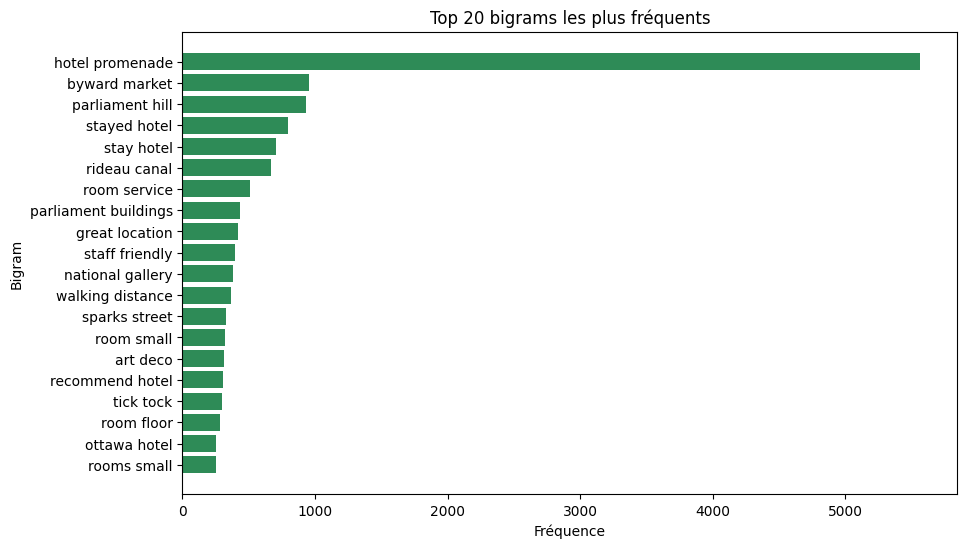

In [13]:
# Visualisation des bigrams
plt.figure(figsize=(10,6))
plt.barh(top_bigrams['ngram'][::-1], top_bigrams['count'][::-1], color='seagreen')
plt.title("Top 20 bigrams les plus fréquents")
plt.xlabel("Fréquence")
plt.ylabel("Bigram")
plt.show()

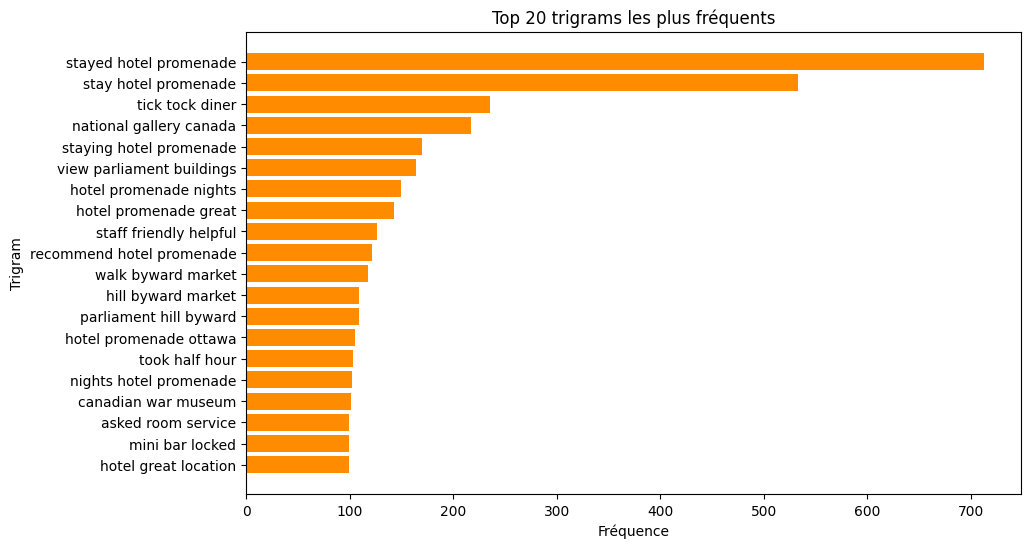

In [14]:
# Visualisation des trigrams
plt.figure(figsize=(10,6))
plt.barh(top_trigrams['ngram'][::-1], top_trigrams['count'][::-1], color='darkorange')
plt.title("Top 20 trigrams les plus fréquents")
plt.xlabel("Fréquence")
plt.ylabel("Trigram")
plt.show()

In [15]:
# Verification des bigrams et trigrams
print("Nombre de bigrams:", len(top_bigrams))
print("Nombre de trigrams:", len(top_trigrams))

Nombre de bigrams: 20
Nombre de trigrams: 20


In [16]:
# Verification des n-grams les plus frequents
print("Bigram le plus fréquent :", top_bigrams.head())
print("Trigram le plus fréquent :", top_trigrams.head())

Bigram le plus fréquent :                  ngram  count
15390  hotel promenade   5568
4241     byward market    954
22612  parliament hill    932
31236     stayed hotel    799
30980       stay hotel    704
Trigram le plus fréquent :                          ngram  count
13705   stayed hotel promenade    713
13573     stay hotel promenade    533
14232          tick tock diner    236
8597   national gallery canada    217
13807  staying hotel promenade    170


# Topic Modeling avec LDA

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorisation (CountVectorizer pour LDA)
vectorizer = CountVectorizer(
    min_df=3, # Ignorer les mots qui apparaissent dans moins de 3 documents
    max_df=0.9, # Ignorer les mots qui apparaissent dans plus de 90% des documents
    ngram_range=(1, 1)) # Unigrammes pour LDA
X_counts = vectorizer.fit_transform(corpus)

In [18]:
# Entrainement du modèle LDA
n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics,
    learning_method='batch',
    random_state=42)
lda.fit(X_counts)

LatentDirichletAllocation(n_components=5, random_state=42)

In [19]:
# Fonction d'extraction des mots cles de chaque topic
def display_topics(model, feature_names, n_top_words=10):
    topics = []
    for idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics.append((idx, top_features))
    return topics

In [20]:
# Affichage des topics
feature_names = vectorizer.get_feature_names_out()
topics = display_topics(lda, feature_names, n_top_words=10)

for topic_id, words in topics:
    print(f"Topic {topic_id}: {', '.join(words)}")

Topic 0: service, hotel, promenade, suite, experience, private, offers, demande, voir, spa
Topic 1: hotel, room, promenade, stay, service, lobby, ottawa, rooms, stayed, staff
Topic 2: hotel, ottawa, room, great, promenade, location, staff, stay, good, parliament
Topic 3: hotel, chambre, tre, bien, petit, promenade, eter, bon, service, prix
Topic 4: room, hotel, check, bathroom, night, good, bed, got, small, staff


In [21]:
# Attribuer un topic a chaque document
doc_topic_dist = lda.transform(X_counts)
df['topic_lda'] = doc_topic_dist.argmax(axis=1)
print(df[['avis_clients', 'topic_lda']].head())

                                        avis_clients  topic_lda
0  Le spa propose un traitement signature exclusi...          3
1  Un séjour correct mais qui ne justifie pas ple...          3
2  The laundry service express saved our gala din...          0
3  L'exposition de collection d'art contemporain ...          3
4  L'emplacement privilégié est parfait pour expl...          0


# Topic Modeling avec BERTopic

In [22]:
! pip install torch bertopic sentence-transformers umap-learn hdbscan keras==2.13

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement keras==2.13 (from versions: 0.2.0, 0.3.0, 0.3.1, 0.3.2, 0.3.3, 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.0.4, 1.0.5, 1.0.6, 1.0.7, 1.0.8, 1.1.0, 1.1.1, 1.1.2, 1.2.0, 1.2.1, 1.2.2, 2.0.0, 2.0.1, 2.0.2, 2.0.3, 2.0.4, 2.0.5, 2.0.6, 2.0.7, 2.0.8, 2.0.9, 2.1.0, 2.1.1, 2.1.2, 2.1.3, 2.1.4, 2.1.5, 2.1.6, 2.2.0, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2.5, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.4.2, 2.4.3, 2.5.0rc0, 2.6.0rc0, 2.6.0rc1, 2.6.0rc2, 2.6.0rc3, 2.6.0, 2.7.0rc0, 2.7.0rc2, 2.7.0, 2.8.0rc0, 2.8.0rc1, 2.8.0, 2.9.0rc0, 2.9.0rc1, 2.9.0rc2, 2.9.0, 2.10.0rc0, 2.10.0rc1, 2.10.0, 2.11.0rc0, 2.11.0rc1, 2.11.0rc2, 2.11.0rc3, 2.11.0, 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.13.1rc0, 2.13.1rc1, 2.13.1, 2.14.0rc0, 2.14.0, 2.15.0rc0, 2.15.0rc1, 2.15.0, 3.0.0, 3.0.1, 3.0.2, 3.0.3, 3.0.4, 3.0.5, 3.1.0, 3.1.1, 3.2.0, 3.2.1, 3.3.0, 3.3.1, 3.3.2, 3.3.3, 3.4.0, 3.4.1, 3.5.0, 3.6.0, 3.7.0, 3.8.0, 3.9.0, 3.9.1, 3.9.2, 3.10.0, 3.11.0, 3.11.1, 3.11.2, 3.11.3, 3.12.0, 3.12.1, 3.13.0, 3.

In [23]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Modèle d'embedding multilingue (FR + EN)
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# Création du modèle BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    verbose=True
)

# Entraînement
topics, probs = topic_model.fit_transform(df["text_lemmas"].tolist())


2026-03-03 17:48:03,296 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/186 [00:00<?, ?it/s]

2026-03-03 17:52:01,685 - BERTopic - Embedding - Completed ✓
2026-03-03 17:52:01,687 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-03 17:52:36,690 - BERTopic - Dimensionality - Completed ✓
2026-03-03 17:52:36,696 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-03 17:52:37,196 - BERTopic - Cluster - Completed ✓
2026-03-03 17:52:37,214 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-03 17:52:37,605 - BERTopic - Representation - Completed ✓


In [24]:
# Afficher les mots cles d'un topic
topic_model.get_topic(0)

[('hotel', np.float64(0.020956899138289103)),
 ('room', np.float64(0.019617531786980943)),
 ('promenade', np.float64(0.01580296998037457)),
 ('ottawa', np.float64(0.01479540002575269)),
 ('stay', np.float64(0.013707571741040845)),
 ('staff', np.float64(0.012946402176127202)),
 ('great', np.float64(0.012771530801044827)),
 ('rooms', np.float64(0.012211621084103374)),
 ('good', np.float64(0.011436388217105808)),
 ('location', np.float64(0.011431521668928314))]

In [25]:
# Ajout des topics au dataframe
df['topic_bertopic'] = topics
print(df[['avis_clients', 'topic_bertopic']].head())

                                        avis_clients  topic_bertopic
0  Le spa propose un traitement signature exclusi...              33
1  Un séjour correct mais qui ne justifie pas ple...              -1
2  The laundry service express saved our gala din...              -1
3  L'exposition de collection d'art contemporain ...              21
4  L'emplacement privilégié est parfait pour expl...              13


In [26]:
# Representation de topics

# Nom automatique des topics
print(topic_model.generate_topic_labels())

# Phrases representatives
print(topic_model.get_representative_docs(0))

['-1_chambre_tre_petit', '0_hotel_room_promenade', '1_tre_chambre_bien', '2_chambre_tre_bien', '3_elegamment_spacieuser_chambre', '4_rare_sommelier_degustation', '5_private_dedicated_offers', '6_gastronomique_cuisine_restaurant', '7_fonctionnelle_salle_bain', '8_spa_luxueux_devenir', '9_limousine_chauffeur_region', '10_piscine_debordemer_offrir', '11_decoration_interieur_elegant', '12_eleve_creation_cocktail', '13_varier_dejeuner_buffet', '14_variet_exceptionnelle_correct', '15_inacceptable_hygiene_bain', '16_diamant_classement_infrastructure', '17_tre_bien_canada', '18_insonorisation_promesse_entrer', '19_resteer_relance_demande', '20_parlement_canada_tre', '21_emplacement_explorer_ville', '22_attribuee_deception_categorie', '23_systeme_reservation_installation', '24_chef_preferences_tasting', '25_garden_rare_species', '26_requete_requests_conciergerie', '27_generalemer_attentif_professionnel', '28_exclusive_private_collections', '29_products_breakfast_presentation', '30_defavorabl_qu

In [27]:
# Nombre de topics
print(df['topic_bertopic'].nunique())

# Distribution des topics
print(df['topic_bertopic'].value_counts())

37
topic_bertopic
 0     4787
-1      339
 1      100
 2       83
 3       44
 4       38
 5       34
 6       32
 7       29
 8       27
 9       24
 10      22
 11      21
 12      20
 13      20
 14      19
 15      19
 16      18
 17      18
 18      18
 19      18
 20      17
 21      17
 22      16
 23      16
 24      15
 25      14
 26      13
 27      13
 28      13
 29      12
 30      12
 31      12
 32      12
 33      11
 34      11
 35      11
Name: count, dtype: int64


# Visualisation complementaires

In [28]:
! pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


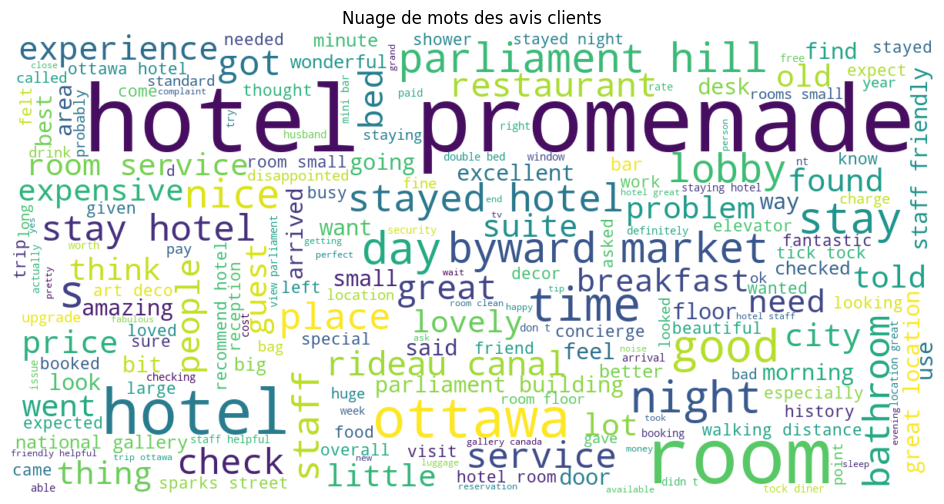

In [29]:
# Nuage de mots
%pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["text_lemmas"].tolist())

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de mots des avis clients")
plt.show()

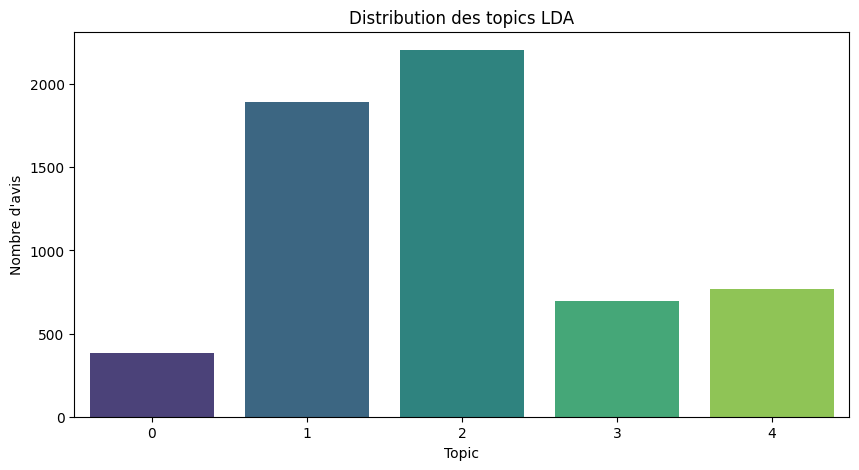

In [30]:
# Distribution des topics LDA
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(x=df["topic_lda"], palette="viridis")
plt.title("Distribution des topics LDA")
plt.xlabel("Topic")
plt.ylabel("Nombre d'avis")
plt.show()


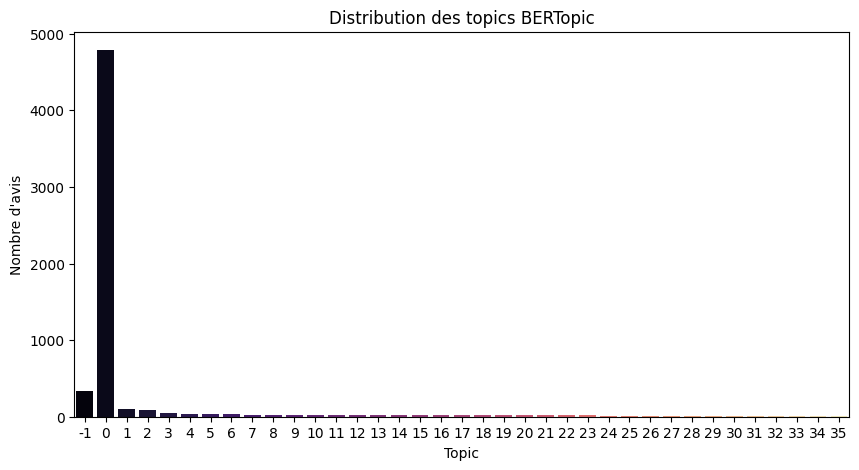

In [31]:
# Distribution des topics BERTopic
plt.figure(figsize=(10,5))
sns.countplot(x=df["topic_bertopic"], palette="magma")
plt.title("Distribution des topics BERTopic")
plt.xlabel("Topic")
plt.ylabel("Nombre d'avis")
plt.show()

In [32]:
# Sauvegarde des scores TF-IDF
tfidf_scores.to_csv('../data/results/tfidf_scores.csv', index=False)

# Sauvegarde des n-grams
top_bigrams.to_csv('../data/results/top_bigrams.csv', index=False)
top_trigrams.to_csv('../data/results/top_trigrams.csv', index=False)

# Sauvegarde des topics LDA

# Recalcul des topics LDA
# Recalcul des topics LDA
topics = display_topics(lda, feature_names, n_top_words=10)

lda_topics_df = pd.DataFrame({
    "topic_id": [t[0] for t in topics],
    "keywords": [", ".join(t[1]) for t in topics]
})
lda_topics_df.to_csv("../data/results/lda_topics.csv", index=False)

# Distribution des topics par avis
df[["avis_clients", "topic_lda"]].to_csv("../data/results/lda_topic_assignments.csv", index=False)

# Sauvegarde des resultats BERTopic

# Topics + mots cles
topic_info = topic_model.get_topic_info()
topic_info.to_csv("../data/results/bertopic_topics.csv", index=False)

# Assignation des topics aux avis
df[["avis_clients", "topic_bertopic"]].to_csv("../data/results/bertopic_topic_assignments.csv", index=False)

# Probabilites des topics
np.save("../data/results/bertopic_probs.npy", probs)

# Sauvegarde du dataframe final
df.to_csv("../data/results/avis_with_topics.csv", index=False)


In [33]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,339,-1_chambre_tre_petit_bien,"[chambre, tre, petit, bien, etage, vue, bon, e...",[hotel idealement situe decouverte d ottawa ac...
1,0,4787,0_hotel_room_promenade_ottawa,"[hotel, room, promenade, ottawa, stay, staff, ...",[stayed week july friend booked room booking w...
2,1,100,1_tre_chambre_bien_petit,"[tre, chambre, bien, petit, personnel, eter, p...",[tre bon sejour hotel immense tre bien situ qu...
3,2,83,2_chambre_tre_bien_petit,"[chambre, tre, bien, petit, eter, bon, faire, ...",[chance aller hotel promenade apre travail lob...
4,3,44,3_elegamment_spacieuser_chambre_eter,"[elegamment, spacieuser, chambre, eter, meuble...",[chambre spacieuser elegamment meublee climati...
5,4,38,4_rare_sommelier_degustation_collection,"[rare, sommelier, degustation, collection, vin...",[culinary experience historic wine cellar tast...
6,5,34,5_private_dedicated_offers_terrace,"[private, dedicated, offers, terrace, intimacy...",[hotel promenade s private terrace hot tub ded...
7,6,32,6_gastronomique_cuisine_restaurant_proposer,"[gastronomique, cuisine, restaurant, proposer,...",[restaurant gastronomique proposer cuisine inv...
8,7,29,7_fonctionnelle_salle_bain_confortable,"[fonctionnelle, salle, bain, confortable, sugg...",[chambre confortable caractere exceptionnel su...
9,8,27,8_spa_luxueux_devenir_therapeute,"[spa, luxueux, devenir, therapeute, heure, det...",[luxueux spa therapeute hautement qualifie esp...


# Analyse thématique des commentaires clients

## 1. Objectif

L’objectif de l’analyse thématique est d’identifier les **thèmes principaux présents dans les commentaires des clients** afin de mieux comprendre les aspects du service hôtelier qui influencent l’expérience des visiteurs.

Cette analyse permet de regrouper les avis clients selon des **catégories récurrentes**, facilitant ainsi l’interprétation des tendances générales et l’identification des points forts ou des axes d’amélioration.

---

## 2. Méthodologie

L’analyse thématique repose sur plusieurs étapes :

1. **Collecte des commentaires clients**  
   Les données proviennent des avis et retours d’expérience des clients concernant leur séjour à l’hôtel.

2. **Nettoyage des données textuelles**  
   Les commentaires ont été prétraités afin de faciliter l’analyse :
   - conversion en minuscules
   - suppression de la ponctuation
   - suppression des mots vides (stopwords)
   - normalisation du texte

3. **Extraction des mots clés**  
   Les termes les plus fréquents ont été identifiés afin de détecter les thèmes récurrents dans les commentaires.

4. **Regroupement par thèmes**  
   Les mots et expressions similaires ont été regroupés afin de former des catégories représentant les principaux aspects de l’expérience client.

---

## 3. Thèmes principaux identifiés

L’analyse des commentaires a permis d’identifier plusieurs thèmes majeurs liés à l’expérience des clients à l’hôtel.

### 3.1 Propreté

La propreté des chambres et des installations est l’un des aspects les plus mentionnés par les clients.

Les commentaires liés à ce thème font référence à :
- la propreté des chambres
- l’entretien des salles de bain
- la qualité du ménage
- l’état général des installations

Ce thème est essentiel car il influence directement la satisfaction et la perception de la qualité du service.

---

### 3.2 Qualité du service

Le service fourni par le personnel de l’hôtel constitue également un thème récurrent dans les commentaires.

Les éléments souvent mentionnés incluent :

- l’accueil à la réception
- la disponibilité du personnel
- la rapidité de réponse aux demandes
- la courtoisie et le professionnalisme

Un service de qualité contribue fortement à une expérience client positive.

---

### 3.3 Localisation

La localisation de l’hôtel est fréquemment mentionnée dans les avis.

Les commentaires font souvent référence à :

- la proximité des attractions touristiques
- l’accès aux transports
- la facilité d’accès aux commerces et restaurants
- la tranquillité du quartier

Une localisation avantageuse peut être un facteur déterminant dans le choix d’un hôtel.

---

### 3.4 Confort des chambres

Plusieurs commentaires abordent le niveau de confort des chambres.

Les aspects mentionnés incluent :

- la qualité des lits
- la taille des chambres
- le niveau de bruit
- la qualité des équipements

Le confort est un élément central de l’expérience de séjour.

---

### 3.5 Installations et services de l’hôtel

Les clients mentionnent également les installations disponibles dans l’hôtel.

Parmi les éléments fréquemment cités :

- la piscine
- le stationnement
- les espaces communs
- les services additionnels proposés aux clients

Ces éléments contribuent à enrichir l’expérience globale du séjour.

---

## 4. Interprétation des résultats

L’analyse thématique permet d’identifier les **facteurs clés influençant la satisfaction des clients**.

Les résultats montrent que l’expérience client est principalement influencée par :

- la propreté des installations
- la qualité du service
- le confort des chambres
- la localisation de l’hôtel
- les installations disponibles

Ces éléments constituent les dimensions principales de l’expérience hôtelière et peuvent servir de base pour orienter les stratégies d’amélioration du service.

---

## 5. Conclusion

L’analyse thématique des commentaires clients permet de transformer des données textuelles non structurées en informations exploitables.

Elle met en évidence les principaux aspects de l’expérience client et fournit des indications précieuses pour :

- améliorer la qualité du service
- identifier les points forts de l’établissement
- détecter les domaines nécessitant des améliorations

Cette approche constitue une étape importante dans l’analyse des avis clients et peut être combinée avec d’autres méthodes d’analyse, comme l’analyse de sentiment, afin d’obtenir une compréhension plus complète de la satisfaction des clients.